,image_path,h11,h12,h13,h21,h22,h23,h31,h32
0,peper/input_images\1.png,1.550024,0.085322,-76.249814,-0.200061,2.200670,-118.436065,-0.000760,0.001391
1,peper/input_images\1frame_0000.png,1.756865,0.111463,-288.996300,0.079723,2.642253,-698.784706,0.000056,0.000388
2,peper/input_images\1frame_0001.jpg,1.782410,0.115527,-295.913089,0.046910,2.685599,-753.539157,0.000049,0.000381
3,peper/input_images\1frame_0002.jpg,1.702126,0.072652,-254.426312,0.032984,2.484775,-556.237677,0.000002,0.000310
4,peper/input_images\1frame_0003.jpg,1.784545,0.088949,-279.211813,0.046527,2.558977,-646.444046,0.000023,0.000314


y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])


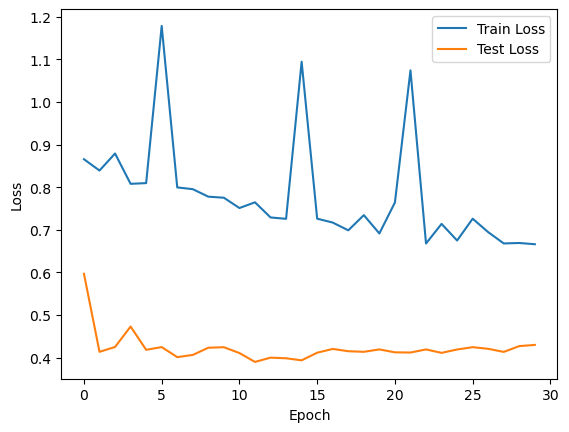

Выровненное изображение сохранено как peper/testing\aligned_4frame_0100.jpg.


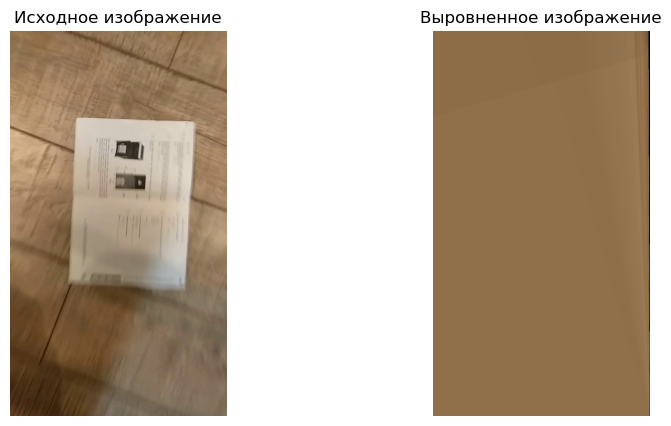

Выровненное изображение сохранено как peper/testing\aligned_4frame_0101.jpg.


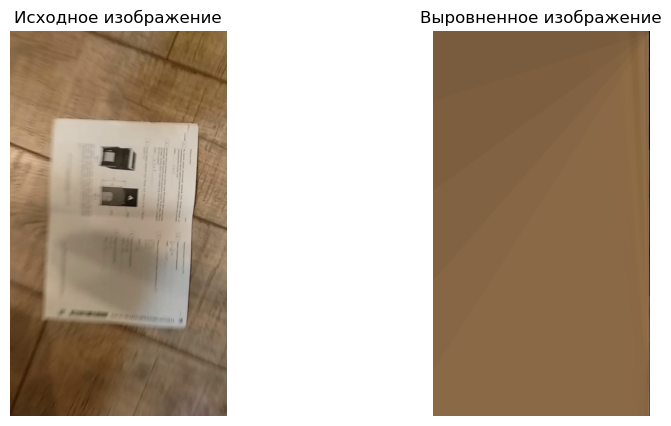

Выровненное изображение сохранено как peper/testing\aligned_4frame_0102.jpg.


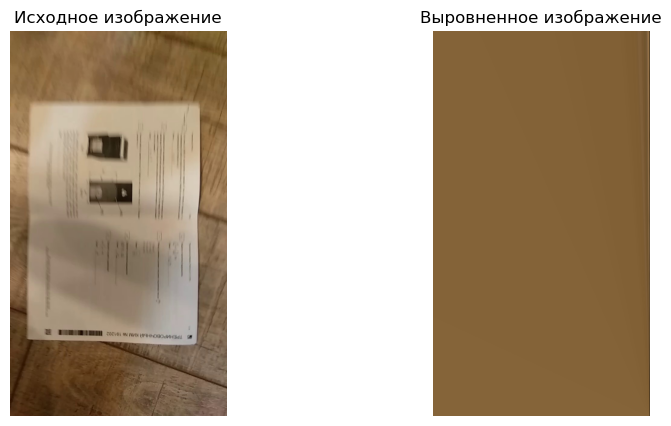

Выровненное изображение сохранено как peper/testing\aligned_4frame_0103.jpg.


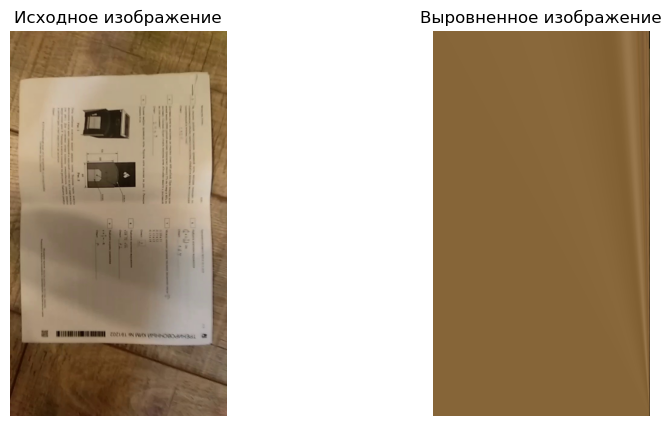

Выровненное изображение сохранено как peper/testing\aligned_4frame_0104.jpg.


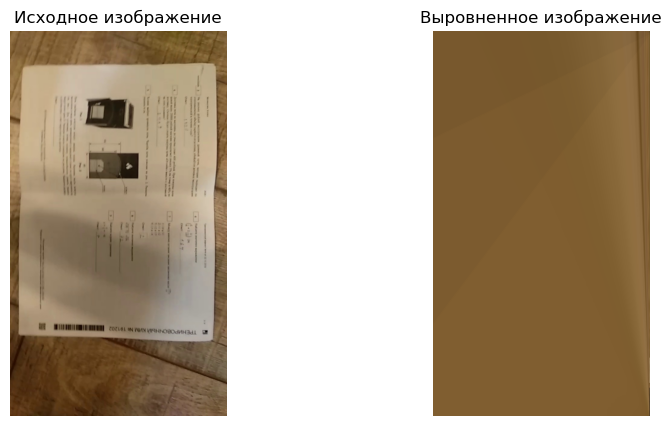

Выровненное изображение сохранено как peper/testing\aligned_4frame_0105.jpg.


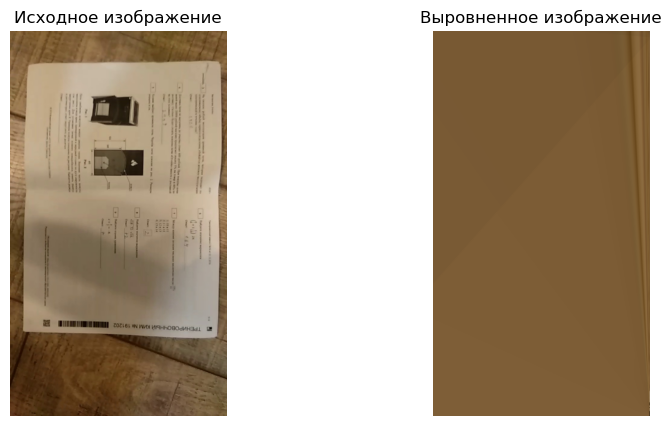

Выровненное изображение сохранено как peper/testing\aligned_aligned_test_image.png.


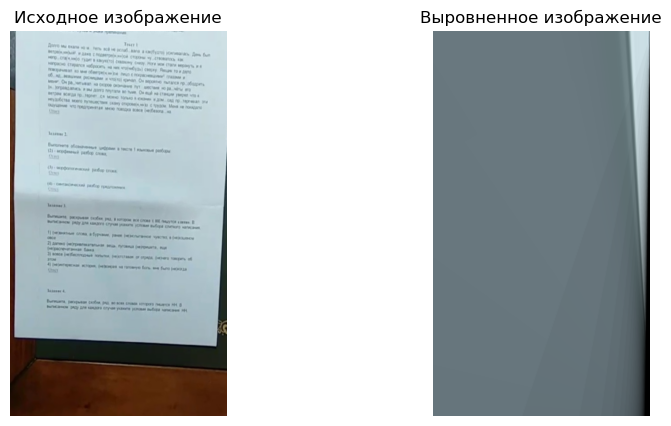

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Пути к данным
PATH = 'peper/'
TRAIN_PATH = PATH + 'fhomography_data.csv'

# Загрузка данных
train_df = pd.read_csv(TRAIN_PATH)
display(train_df.head())

# Нормализация параметров гомографии
scaler = StandardScaler()
train_labels = scaler.fit_transform(train_df.iloc[:, 1:].values)  # Нормализуем параметры

# Преобразование данных
train_images = []
train_sizes = []  # Сохраняем исходные размеры изображений
valid_images = []
valid_indices = []

for idx, img_path in enumerate(train_df['image_path']):
    try:
        img = cv2.imread(img_path)
        if img is not None:
            train_images.append(img)
            train_sizes.append(img.shape[:2])  # Сохраняем (height, width)
        else:
            valid_indices.append(idx)  # Запоминаем индексы пропущенных изображений
    except Exception as e:
        print(f"Ошибка при загрузке изображения {img_path}: {e}")

# Удаляем пропущенные изображения из меток
train_labels = np.delete(train_labels, valid_indices, axis=0)

# Разделение данных на обучающую и тестовую выборки
train_images, test_images, train_labels, test_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=101
)

# Преобразования для изображений
t = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),  # Подгоняем все изображения до одного размера
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Функция для преобразования параметров гомографии в координаты углов
def homography_to_corners(H, width, height):
    """
    Преобразует матрицу гомографии в координаты углов листа бумаги.

    Параметры:
        H (np.array): Матрица гомографии 3x3.
        width (int): Ширина изображения.
        height (int): Высота изображения.

    Возвращает:
        np.array: Координаты углов листа бумаги.
    """
    # Исходные углы (в однородных координатах)
    src_corners = np.array([
        [0, 0],  # Верхний левый
        [width, 0],  # Верхний правый
        [width, height],  # Нижний правый
        [0, height]  # Нижний левый
    ], dtype="float32")

    # Преобразуем углы с помощью матрицы гомографии
    dst_corners = cv2.perspectiveTransform(src_corners.reshape(-1, 1, 2), H)

    # Возвращаем координаты углов
    return dst_corners.reshape(4, 2)

# Класс для создания датасета
class CreateDataset(Dataset):
    def __init__(self, X, y, sizes, transform=None):
        self.X = X
        self.y = y
        self.sizes = sizes  # Исходные размеры изображений
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        inp = self.X[idx].astype(np.float32)
        out = self.y[idx].astype(np.float32)
        original_size = self.sizes[idx]  # Исходные размеры изображения

        if self.transform:
            # Применяем преобразования к изображению
            inp = self.transform(inp)

            # Преобразуем параметры гомографии в координаты углов
            H = np.append(out, 1.0).reshape(3, 3)  # Преобразуем вектор в матрицу 3x3
            corners = homography_to_corners(H, original_size[1], original_size[0])

            # Масштабируем координаты углов
            scale_x = 256 / original_size[1]
            scale_y = 256 / original_size[0]
            corners[:, 0] *= scale_x  # Масштабируем координаты x
            corners[:, 1] *= scale_y  # Масштабируем координаты y
            out = corners.flatten()  # Возвращаем в виде одномерного массива

        return inp, out

# Создание датасетов и загрузчиков
train_dataset = CreateDataset(train_images, train_labels, train_sizes, transform=t)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)

test_dataset = CreateDataset(test_images, test_labels, train_sizes, transform=t)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=32)

# Использование предобученной модели (ResNet) в качестве энкодера
class CornerNet(nn.Module):
    def __init__(self):
        super(CornerNet, self).__init__()
        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()  # Убираем последний слой ResNet
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 8)  # Предсказываем 8 координат (4 точки)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.fc(features)

# Обучение модели
EPOCHS = 30  # Количество эпох
net = CornerNet()
criterion = nn.SmoothL1Loss()  # Используем Smooth L1 Loss
optimizer = AdamW(net.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)  # Learning Rate Scheduler

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    net.train()
    running_loss = 0.0
    for data in train_loader:
        X_train, y_train = data
        optimizer.zero_grad()
        y_pred = net(X_train)

        # Проверка размерностей
        print(f"y_pred shape: {y_pred.shape}")  # Должно быть (batch_size, 8)
        print(f"y_train shape: {y_train.shape}")  # Должно быть (batch_size, 8)

        train_loss = criterion(y_pred, y_train)
        train_loss.backward()
        optimizer.step()
        running_loss += train_loss.item()
    train_losses.append(running_loss / len(train_loader))
    scheduler.step()

    # Тестирование на валидационной выборке
    net.eval()
    test_loss = 0.0
    with torch.no_grad():
        for data in test_loader:
            X_test, y_test = data
            output = net(X_test)
            test_loss += criterion(output, y_test).item()
    test_losses.append(test_loss / len(test_loader))

    print(f"Epoch: {epoch + 1}, Train Loss: {train_losses[-1]}, Test Loss: {test_losses[-1]}")

# Визуализация потерь
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Функция для обработки всех изображений из папки
def process_folder(input_folder, output_folder, model, scaler):
    """
    Обрабатывает все изображения из папки, применяет модель для выравнивания и сохраняет результаты.
    
    Параметры:
        input_folder (str): Путь к папке с исходными изображениями.
        output_folder (str): Путь к папке для сохранения выровненных изображений.
        model (nn.Module): Обученная модель.
        scaler (StandardScaler): Scaler, используемый для нормализации данных.
    """
    # Создаём папку для сохранения результатов, если её нет
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Получаем список всех изображений в папке
    image_files = [f for f in os.listdir(input_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

    # Обрабатываем каждое изображение
    for image_file in image_files:
        input_path = os.path.join(input_folder, image_file)
        output_path = os.path.join(output_folder, f"aligned_{image_file}")

        # Загружаем и обрабатываем изображение
        try:
            # Преобразования для изображения
            transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((256, 256)),
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])

            # Загрузка и предобработка изображения
            image = cv2.imread(input_path)
            if image is None:
                print(f"Ошибка: Не удалось загрузить изображение {input_path}.")
                continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_tensor = transform(image_rgb).unsqueeze(0)  # Добавляем batch dimension

            # Предсказываем координаты углов
            with torch.no_grad():
                predicted_corners = model(image_tensor)

            # Обратная нормализация координат
            predicted_corners = scaler.inverse_transform(predicted_corners.numpy())

            # Преобразуем координаты в массив 4x2
            predicted_corners = predicted_corners.reshape(4, 2)

            # Определяем целевые точки для выравнивания
            height, width = image.shape[:2]
            dst = np.array([
                [0, 0],
                [width - 1, 0],
                [width - 1, height - 1],
                [0, height - 1]], dtype="float32")

            # Вычисляем матрицу гомографии
            M = cv2.getPerspectiveTransform(predicted_corners.astype("float32"), dst)

            # Выравниваем изображение
            aligned_image = cv2.warpPerspective(image, M, (width, height))

            # Сохраняем результат
            cv2.imwrite(output_path, aligned_image)
            print(f"Выровненное изображение сохранено как {output_path}.")

            # Показываем результат
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            ax[0].set_title("Исходное изображение")
            ax[0].axis('off')

            ax[1].imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
            ax[1].set_title("Выровненное изображение")
            ax[1].axis('off')

            plt.show()

        except Exception as e:
            print(f"Ошибка при обработке изображения {input_path}: {e}")

# Пример использования
input_folder = "peper/extracted_frames"  # Папка с исходными изображениями
output_folder = "peper/testing"   # Папка для сохранения выровненных изображений

# Обрабатываем все изображения в папке
process_folder(input_folder, output_folder, net, scaler)

In [6]:
import pandas as pd
import numpy as np
import os
import cv2

# Загрузка CSV-файла
csv_path = "peper/homography_data.csv"
df = pd.read_csv(csv_path)

# Папка для сохранения аннотаций
output_annotations_dir = "peper/yolo_annotations"
os.makedirs(output_annotations_dir, exist_ok=True)

# Класс для листа бумаги (например, 0)
class_id = 0

# Функция для преобразования матрицы гомографии в координаты углов
def homography_to_corners(H, width, height):
    """
    Преобразует матрицу гомографии в координаты углов листа бумаги.

    Параметры:
        H (np.array): Матрица гомографии 3x3.
        width (int): Ширина изображения.
        height (int): Высота изображения.

    Возвращает:
        np.array: Координаты углов листа бумаги.
    """
    # Исходные углы (в однородных координатах)
    src_corners = np.array([
        [0, 0],  # Верхний левый
        [width, 0],  # Верхний правый
        [width, height],  # Нижний правый
        [0, height]  # Нижний левый
    ], dtype="float32")

    # Преобразуем углы с помощью матрицы гомографии
    dst_corners = cv2.perspectiveTransform(src_corners.reshape(-1, 1, 2), H)

    # Возвращаем координаты углов
    return dst_corners.reshape(4, 2)

# Обработка каждой строки в CSV
for index, row in df.iterrows():
    image_path = row['image_path']
    H = np.array([
        [row['h11'], row['h12'], row['h13']],
        [row['h21'], row['h22'], row['h23']],
        [row['h31'], row['h32'], 1.0]
    ], dtype="float32")

    # Загрузка изображения для получения размеров
    image = cv2.imread(image_path)
    if image is None:
        print(f"Ошибка: Не удалось загрузить изображение {image_path}.")
        continue
    height, width, _ = image.shape

    # Вычисляем обратную матрицу гомографии
    H_inv = np.linalg.inv(H)

    # Преобразуем матрицу гомографии в координаты углов
    corners = homography_to_corners(H_inv, width, height)
    print(f"Координаты углов для {image_path}:")
    print(corners)

    # Ограничиваем координаты углов рамками изображения
    corners[:, 0] = np.clip(corners[:, 0], 0, width)  # Ограничиваем x
    corners[:, 1] = np.clip(corners[:, 1], 0, height)  # Ограничиваем y

    # Вычисляем bounding box на основе ограниченных координат углов
    x_coords = [corner[0] for corner in corners]
    y_coords = [corner[1] for corner in corners]
    x_min = min(x_coords)
    x_max = max(x_coords)
    y_min = min(y_coords)
    y_max = max(y_coords)
    print(f"Bounding box: x_min={x_min}, x_max={x_max}, y_min={y_min}, y_max={y_max}")

    # Нормализация координат bounding box
    x_center = (x_min + x_max) / 2 / width
    y_center = (y_min + y_max) / 2 / height
    box_width = (x_max - x_min) / width
    box_height = (y_max - y_min) / height
    print(f"Normalized: x_center={x_center}, y_center={y_center}, width={box_width}, height={box_height}")

    # Сохраняем аннотацию в YOLO-формате
    annotation = f"{class_id} {x_center} {y_center} {box_width} {box_height}"
    annotation_file = os.path.join(output_annotations_dir, os.path.basename(image_path).replace(".png", ".txt").replace(".jpg", ".txt"))
    with open(annotation_file, "w") as f:
        f.write(annotation)

    print(f"Аннотация для {image_path} сохранена в {annotation_file}.")

Координаты углов для peper/input_images\1.png:
[[ 46.  58.]
 [200.  72.]
 [230. 268.]
 [ 34. 276.]]
Bounding box: x_min=34.0, x_max=230.0, y_min=58.0, y_max=276.0
Normalized: x_center=0.5217391304347826, y_center=0.4704225352112676, width=0.7747035573122529, height=0.6140845070422535
Аннотация для peper/input_images\1.png сохранена в peper/yolo_annotations\1.txt.
Координаты углов для peper/input_images\1frame_0000.png:
[[148.00002  260.      ]
 [612.       246.00002 ]
 [678.       920.      ]
 [106.000015 922.      ]]
Bounding box: x_min=106.00001525878906, x_max=678.0, y_min=246.00001525878906, y_max=922.0
Normalized: x_center=0.5444444444444444, y_center=0.45625, width=0.7944444444444444, height=0.528125
Аннотация для peper/input_images\1frame_0000.png сохранена в peper/yolo_annotations\1frame_0000.txt.
Координаты углов для peper/input_images\1frame_0001.jpg:
[[147.99998 278.     ]
 [605.99994 270.     ]
 [665.99994 930.     ]
 [106.      926.     ]]
Bounding box: x_min=106.0, x_max=